In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from prophet import Prophet

/Users/rosamariasierraalmeria/Documents/GitHub/Impacto-del-clima-en-la-agricultura-/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
df_clima_agricultura = pd.read_parquet('dataset_analitico_filtrado.parquet')

In [ ]:
# Variables predictoras y objetivo
#features_sin_anio = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                     #"PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

# Eliminar filas con NaN en Hectareas
#df_modelo = df_clima_agricultura.dropna(subset=["Hectareas"]).copy()

#Usamos .copy en la variable X porque vamos a modificar columnas cuando usemos .get_dummies
#X = df_modelo[features].copy()
#y = df_modelo["Hectareas"].values

# Convertir categóricas en numéricas.
# .get_dummies convierte los valores categóricos en 0 y 1.
#X = pd.get_dummies(X, columns=["Cultivo", "Provincia"])

#print(X.shape)
#print(f"NaN en y: {np.isnan(y).sum()}")

(10944, 26)
NaN en y: 0


In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(
    #X, y, 
    #test_size=0.2, 
    #random_state=42
#)

#print(f"Entrenamiento: {X_train.shape}")
#print(f"Test: {X_test.shape}")

Entrenamiento: (8755, 26)
Test: (2189, 26)


In [ ]:
#rf_clima_agricultura = RandomForestRegressor(
    #n_estimators=100,
    #random_state=42,
    #n_jobs=-1
#)

#rf_clima_agricultura.fit(X_train, y_train)
#print("Modelo entrenado")

Modelo entrenado


In [ ]:
#y_pred = rf_clima_agricultura.predict(X_test)

#print(f"R²:  {r2_score(y_test, y_pred):.3f}")
#print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
#print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  1.000
MAE: 0.00
RMSE: 0.00


#### **Modelo predictivo - Random Forest por cultivo**

##### Enfoque
Tras detectar overfitting en el modelo global (R²=1.0) debido a la alta 
duplicidad de valores climáticos entre cultivos, se optó por entrenar un 
modelo independiente por cultivo. Esto permite capturar la relación 
específica entre clima y hectáreas para cada tipo de cultivo.

In [75]:
# Eliminar filas con NaN en Hectareas
df_modelo = df_clima_agricultura.dropna(subset=["Hectareas"]).copy()
print(df_modelo["Provincia"].unique())
print(df_modelo.shape)

<ArrowStringArray>
['VALLADOLID', 'VALENCIA', 'LA RIOJA', 'JAEN']
Length: 4, dtype: str
(20352, 16)


In [76]:
# Filtrar solo trigo
trigos = ["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO"]
df_trigo = df_modelo[df_modelo["Cultivo"].isin(trigos)].copy()

print(f"Filas de trigo: {len(df_trigo)}")
print(f"Provincias: {df_trigo['Provincia'].unique()}")

Filas de trigo: 3480
Provincias: <ArrowStringArray>
['VALLADOLID', 'VALENCIA', 'LA RIOJA', 'JAEN']
Length: 4, dtype: str


In [77]:
features_trigo = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                  "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "Provincia"]

X_trigo = pd.get_dummies(df_trigo[features_trigo].copy(), columns=["Provincia"])
y_trigo = df_trigo["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_trigo, y_trigo, test_size=0.2, random_state=42
)

rf_trigo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_trigo.fit(X_train, y_train)

y_pred = rf_trigo.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  0.444
MAE: 12577.95
RMSE: 22373.80


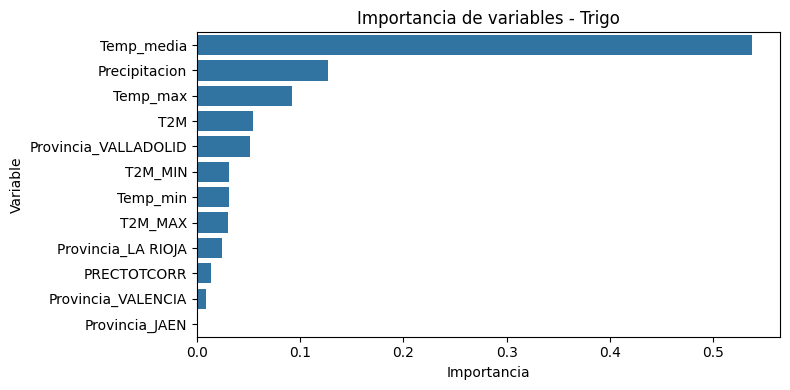

In [78]:
importancia = pd.DataFrame({
    "Variable": X_trigo.columns,
    "Importancia": rf_trigo.feature_importances_
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importancia, x="Importancia", y="Variable")
plt.title("Importancia de variables - Trigo")
plt.tight_layout()
plt.show()

#### **Modelo Trigo (TRIGO DURO + TRIGO BLANDO Y SEMIDURO)**
**Provincias**: Valladolid y Valencia  
**Filas de entrenamiento**: 1.848

**Métricas:**
- R² = 0.444: el modelo explica el 44% de la varianza en hectáreas de trigo
- MAE = 12.578 hectáreas de error medio
- RMSE = 22.374, indica presencia de errores grandes en algunos casos

El clima explica casi la mitad de la variación en la superficie de trigo, siendo el resto atribuible a factores no climáticos como política agraria o precios de mercado.

#### Importancia de variables
- **Temp_max y Temp_media** son las variables más influyentes (0.22 y 0.19), coherente con el impacto del calor en la floración del trigo.
- **La provincia** tiene un peso significativo (0.13 y 0.11), confirmando que el comportamiento del trigo difiere mucho entre Valladolid y Valencia.
- **Temp_min** también es relevante (0.10), reflejando el efecto de las heladas tardías.
- **Precipitación** tiene un peso bajo (0.05), sugiriendo que la temperatura es más determinante que la lluvia para este cultivo.
- **Variables NASA** tienen muy poco peso, confirmando que AEMET es más representativa para España.

In [79]:
aceitunas = ["ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA"]
df_aceituna = df_modelo[df_modelo["Cultivo"].isin(aceitunas)].copy()

print(f"Filas de aceituna: {len(df_aceituna)}")
print(f"Provincias: {df_aceituna['Provincia'].unique()}")

Filas de aceituna: 4152
Provincias: <ArrowStringArray>
['VALENCIA', 'JAEN', 'VALLADOLID', 'LA RIOJA']
Length: 4, dtype: str


In [85]:
aceitunas = ["ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA"]
df_aceituna = df_modelo[df_modelo["Cultivo"].isin(aceitunas)].copy()

print(f"Filas de aceituna: {len(df_aceituna)}")
print(f"Provincias: {df_aceituna['Provincia'].unique()}")

Filas de aceituna: 4152
Provincias: <ArrowStringArray>
['VALENCIA', 'JAEN', 'VALLADOLID', 'LA RIOJA']
Length: 4, dtype: str


In [86]:
features_aceituna = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                     "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "Provincia"]

X_aceituna = pd.get_dummies(df_aceituna[features_aceituna].copy(), columns=["Provincia"])
y_aceituna = df_aceituna["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_aceituna, y_aceituna, test_size=0.2, random_state=42
)

rf_aceituna = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_aceituna.fit(X_train, y_train)

y_pred = rf_aceituna.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  0.299
MAE: 85839.04
RMSE: 155755.35


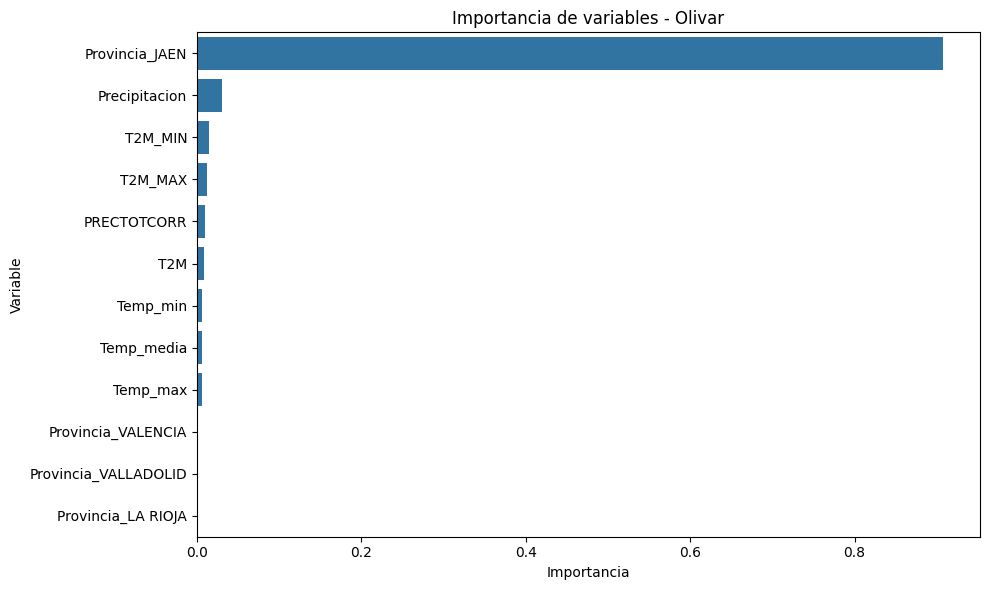

In [87]:
importancia_aceituna = pd.DataFrame({
    "Variable": X_aceituna.columns,
    "Importancia": rf_aceituna.feature_importances_
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_aceituna, x="Importancia", y="Variable")
plt.title("Importancia de variables - Olivar")
plt.tight_layout()
plt.show()

In [89]:
df_aceituna_jaen = df_modelo[
    (df_modelo["Cultivo"].isin(aceitunas)) & 
    (df_modelo["Provincia"] == "JAEN")
].copy()

print(f"Filas: {len(df_aceituna_jaen)}")

features_jaen = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                 "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

X_jaen = df_aceituna_jaen[features_jaen].copy()
y_jaen = df_aceituna_jaen["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_jaen, y_jaen, test_size=0.2, random_state=42
)

rf_aceituna_jaen = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_aceituna_jaen.fit(X_train, y_train)

y_pred = rf_aceituna_jaen.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Filas: 1296
R²:  -0.002
MAE: 274022.08
RMSE: 288224.27


#### Primer enfoque: todas las provincias
**Cultivos**: Aceituna de Mesa, Aceituna de Doble Aptitud, Aceituna de Almazara  
**Provincias**: Valencia, Jaén, Valladolid y La Rioja  
**Filas de entrenamiento**: 4.152

**Métricas:**
- R² = 0.299: el modelo explica solo el 30% de la varianza
- MAE = 85.839 hectáreas de error medio
- RMSE = 155.755, errores muy grandes

El análisis de importancia de variables reveló que `Provincia_JAEN` acapara el 92% de la importancia, lo que indica que el modelo aprende únicamente 
que Jaén tiene muchas más hectáreas que el resto de provincias, sin aprender nada sobre la relación clima-olivar.

#### Segundo enfoque: solo Jaén
Dado que Jaén concentra prácticamente todo el olivar, se entrenó un modelo exclusivamente con datos de esta provincia para aislar la relación clima-hectáreas.

**Filas de entrenamiento**: 1.296

**Métricas:**
- R² = -0.002: el modelo es peor que predecir la media
- MAE = 274.022 hectáreas
- RMSE = 288.224

#### Conclusión
El olivar en Jaén presenta una superficie muy estable a lo largo del período analizado, como se confirmó en el análisis de evolución temporal. Esta estabilidad 
implica que no hay variación suficiente que el modelo pueda relacionar con el clima. 

**El olivar es el cultivo menos predecible con este dataset**, no porque el clima no influya en él, sino porque su superficie es estructuralmente estable e 
independiente de las variaciones climáticas interanuales.

In [91]:
vinos = ["UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION"]
df_vino = df_modelo[df_modelo["Cultivo"].isin(vinos)].copy()

print(f"Filas de viñedo: {len(df_vino)}")
print(f"Provincias: {df_vino['Provincia'].unique()}")

Filas de viñedo: 2184
Provincias: <ArrowStringArray>
['VALLADOLID', 'VALENCIA', 'LA RIOJA', 'JAEN']
Length: 4, dtype: str


In [92]:
features_vino = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                 "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "Provincia"]

X_vino = pd.get_dummies(df_vino[features_vino].copy(), columns=["Provincia"])
y_vino = df_vino["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_vino, y_vino, test_size=0.2, random_state=42
)

rf_vino = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_vino.fit(X_train, y_train)

y_pred = rf_vino.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  0.791
MAE: 3758.92
RMSE: 10795.97


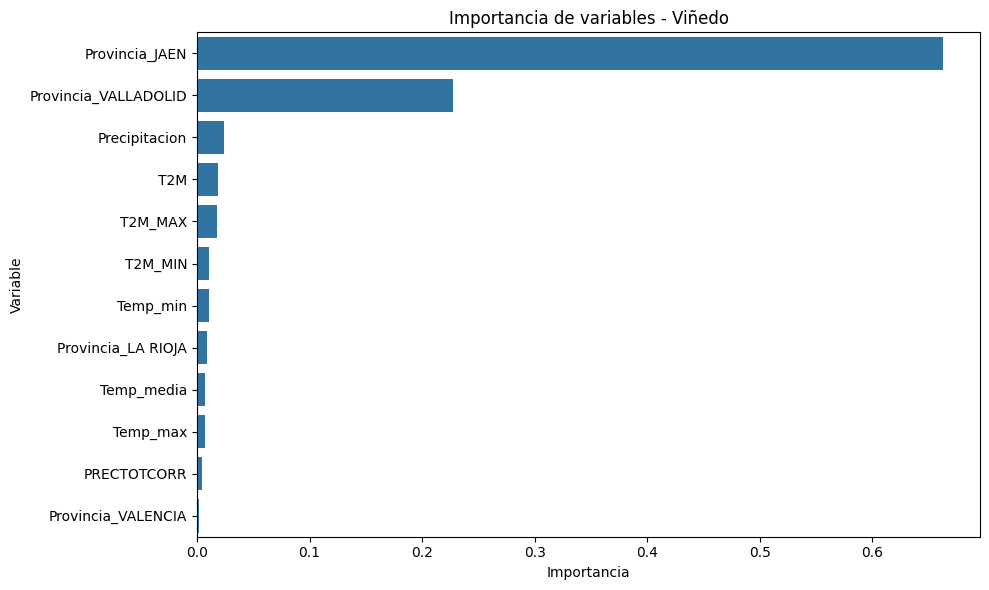

In [93]:
importancia_vino = pd.DataFrame({
    "Variable": X_vino.columns,
    "Importancia": rf_vino.feature_importances_
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_vino, x="Importancia", y="Variable")
plt.title("Importancia de variables - Viñedo")
plt.tight_layout()
plt.show()

In [95]:
df_vino_rioja_vll = df_modelo[
    (df_modelo["Cultivo"].isin(vinos)) & 
    (df_modelo["Provincia"].isin(["LA RIOJA", "VALLADOLID"]))
].copy()

print(f"Filas: {len(df_vino_rioja_vll)}")

features_vino2 = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                  "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "Provincia"]

X_vino2 = pd.get_dummies(df_vino_rioja_vll[features_vino2].copy(), columns=["Provincia"])
y_vino2 = df_vino_rioja_vll["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_vino2, y_vino2, test_size=0.2, random_state=42
)

rf_vino2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_vino2.fit(X_train, y_train)

y_pred = rf_vino2.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Filas: 960
R²:  1.000
MAE: 0.00
RMSE: 0.00


In [96]:
features_vino3 = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                  "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

X_vino3 = df_vino_rioja_vll[features_vino3].copy()
y_vino3 = df_vino_rioja_vll["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_vino3, y_vino3, test_size=0.2, random_state=42
)

rf_vino3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_vino3.fit(X_train, y_train)

y_pred = rf_vino3.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  1.000
MAE: 0.00
RMSE: 0.00


#### **Modelo predictivo - Viñedo**

##### Primer enfoque: todas las provincias
**Cultivos**: Uva de Mesa, Uva de Transformación  
**Provincias**: Valencia, Jaén, Valladolid y La Rioja  
**Filas de entrenamiento**: 2.184

**Métricas:**
- R² = 0.791: aparentemente el mejor modelo
- MAE = 3.759 hectáreas
- RMSE = 10.796

Sin embargo el análisis de importancia de variables reveló que `Provincia_JAEN` 
acapara el 65% de la importancia y `Provincia_VALLADOLID` el 23%. El modelo 
aprende que Jaén tiene muy pocas hectáreas de viñedo y el resto más, sin aprender 
nada sobre la relación clima-viñedo. El buen R² es por tanto engañoso.

#### **Segundo enfoque: solo La Rioja y Valladolid**
Se filtraron las provincias vitivinícolas reales eliminando Jaén y Valencia.

**Filas**: 960

**Métricas:**
- R² = 1.000
- MAE = 0.00
- RMSE = 0.00

Overfitting perfecto. Con solo 2 provincias y múltiples cultivos compartiendo 
los mismos valores climáticos por año, el modelo memoriza perfectamente los datos 
sin aprender ningún patrón real.

#### **Conclusión y limitación estructural**
El viñedo presenta una limitación estructural del dataset: con solo 4 estaciones 
climáticas y múltiples cultivos compartiendo los mismos valores de clima por año, 
el modelo no puede distinguir entre cultivos con el mismo clima y memoriza en 
lugar de aprender.

La solución requeriría datos climáticos a nivel provincial para todas las 
provincias de España, no solo 4 estaciones de referencia. Esta limitación 
afecta especialmente a cultivos con poca variabilidad superficial interanual.

In [97]:
citricos = ["NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"]
df_citricos = df_modelo[df_modelo["Cultivo"].isin(citricos)].copy()

print(f"Filas de cítricos: {len(df_citricos)}")
print(f"Provincias: {df_citricos['Provincia'].unique()}")

Filas de cítricos: 1800
Provincias: <ArrowStringArray>
['VALENCIA', 'JAEN']
Length: 2, dtype: str


In [99]:
features_citricos = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
                     "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "Provincia"]

X_citricos = pd.get_dummies(df_citricos[features_citricos].copy(), columns=["Provincia"])
y_citricos = df_citricos["Hectareas"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_citricos, y_citricos, test_size=0.2, random_state=42
)

rf_citricos = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_citricos.fit(X_train, y_train)

y_pred = rf_citricos.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²:  0.022
MAE: 22672.98
RMSE: 24347.18


In [101]:
# Preparar datos para Prophet (requiere columnas 'ds' y 'y')
df_prophet_trigo = df_modelo[
    df_modelo["Cultivo"].isin(["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO"])
].groupby("Anio")["Hectareas"].sum().reset_index()

df_prophet_trigo.columns = ["ds", "y"]
df_prophet_trigo["ds"] = pd.to_datetime(df_prophet_trigo["ds"], format="%Y")

print(df_prophet_trigo.head())

          ds             y
0 2005-01-01  2.482935e+06
1 2006-01-01  1.966726e+06
2 2007-01-01  1.823129e+06
3 2008-01-01  2.325677e+06
4 2009-01-01  1.790609e+06


00:36:08 - cmdstanpy - INFO - Chain [1] start processing
00:36:08 - cmdstanpy - INFO - Chain [1] done processing


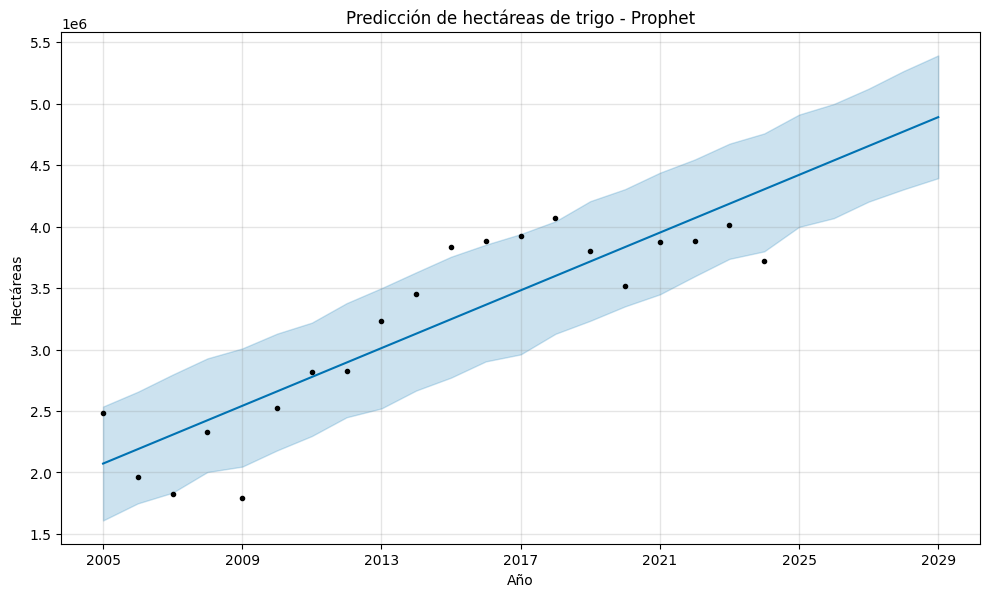

In [103]:
modelo_prophet = Prophet(yearly_seasonality=False)
modelo_prophet.fit(df_prophet_trigo)

# Predecir 5 años hacia el futuro
futuro = modelo_prophet.make_future_dataframe(periods=5, freq="YE")
prediccion = modelo_prophet.predict(futuro)

modelo_prophet.plot(prediccion)
plt.title("Predicción de hectáreas de trigo - Prophet")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

In [105]:
# Añadir variables climáticas al DataFrame de Prophet
df_prophet_trigo_clima = df_modelo[
    df_modelo["Cultivo"].isin(["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO"])
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_trigo_clima.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_trigo_clima["ds"] = pd.to_datetime(df_prophet_trigo_clima["ds"], format="%Y")

print(df_prophet_trigo_clima.head())

          ds             y  Temp_media  Precipitacion
0 2005-01-01  2.482935e+06   16.705815     290.875000
1 2006-01-01  1.966726e+06   16.466676     393.400000
2 2007-01-01  1.823129e+06   15.213970     464.400000
3 2008-01-01  2.325677e+06   16.188165     511.342857
4 2009-01-01  1.790609e+06   16.164852     426.000000


00:39:58 - cmdstanpy - INFO - Chain [1] start processing
00:39:58 - cmdstanpy - INFO - Chain [1] done processing


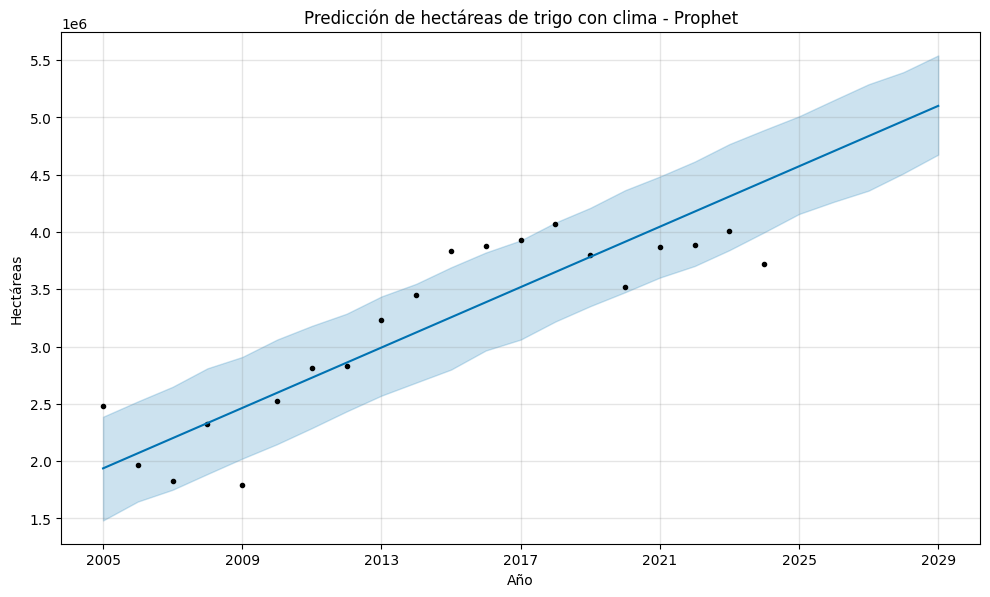

In [106]:
modelo_prophet_clima = Prophet(yearly_seasonality=False)
modelo_prophet_clima.add_regressor("Temp_media")
modelo_prophet_clima.add_regressor("Precipitacion")

modelo_prophet_clima.fit(df_prophet_trigo_clima)

# Para predecir necesitamos valores futuros del clima
# Usamos la media histórica como estimación
futuro = modelo_prophet_clima.make_future_dataframe(periods=5, freq="YE")
futuro["Temp_media"] = df_prophet_trigo_clima["Temp_media"].mean()
futuro["Precipitacion"] = df_prophet_trigo_clima["Precipitacion"].mean()

prediccion = modelo_prophet_clima.predict(futuro)

modelo_prophet_clima.plot(prediccion)
plt.title("Predicción de hectáreas de trigo con clima - Prophet")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

In [107]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_real = df_prophet_trigo_clima["y"].values
y_pred = prediccion[prediccion["ds"].isin(df_prophet_trigo_clima["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

R²:  0.758
MAE: 312980.47
RMSE: 379672.02


In [108]:
df_prophet_olivar = df_modelo[
    df_modelo["Cultivo"].isin(aceitunas)
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_olivar.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_olivar["ds"] = pd.to_datetime(df_prophet_olivar["ds"], format="%Y")

modelo_prophet_olivar = Prophet(yearly_seasonality=False)
modelo_prophet_olivar.add_regressor("Temp_media")
modelo_prophet_olivar.add_regressor("Precipitacion")
modelo_prophet_olivar.fit(df_prophet_olivar)

futuro = modelo_prophet_olivar.make_future_dataframe(periods=5, freq="YE")
futuro["Temp_media"] = df_prophet_olivar["Temp_media"].mean()
futuro["Precipitacion"] = df_prophet_olivar["Precipitacion"].mean()

prediccion = modelo_prophet_olivar.predict(futuro)

y_real = df_prophet_olivar["y"].values
y_pred = prediccion[prediccion["ds"].isin(df_prophet_olivar["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

00:44:31 - cmdstanpy - INFO - Chain [1] start processing
00:44:31 - cmdstanpy - INFO - Chain [1] done processing


R²:  0.993
MAE: 9777.73
RMSE: 14483.51
